
## Lab1_2: Seaborn (From Matplolib and pandas to seaborn)

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Laboratorio_1.2
* Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galón.csv. Contruya el fit de al $95$ C.L.     



  



In [4]:
url = "https://raw.githubusercontent.com/anferivera/Fisica_Computacional_1/refs/heads/main/Sesiones/seaborn/millas_por_galon.csv"

# Convertir a DataFrame:
df = pd.read_csv(url)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


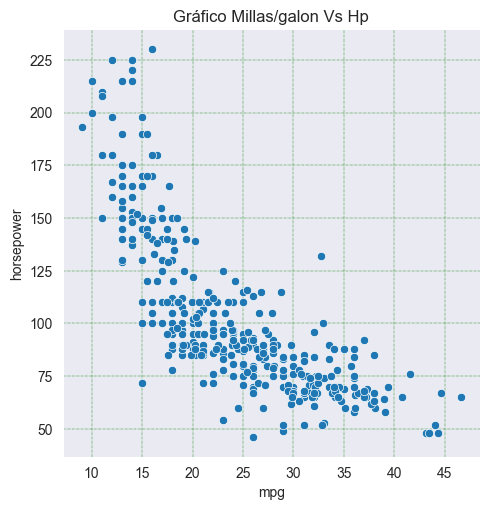

In [13]:
# Gráfica de datos:
sns.set_style('dark')

sns.relplot(data=df,
            x = 'mpg',
            y = 'horsepower')

plt.grid(True, color='green', linestyle='-.', linewidth=0.3)
plt.title('Gráfico Millas/galon Vs Hp')
plt.show()

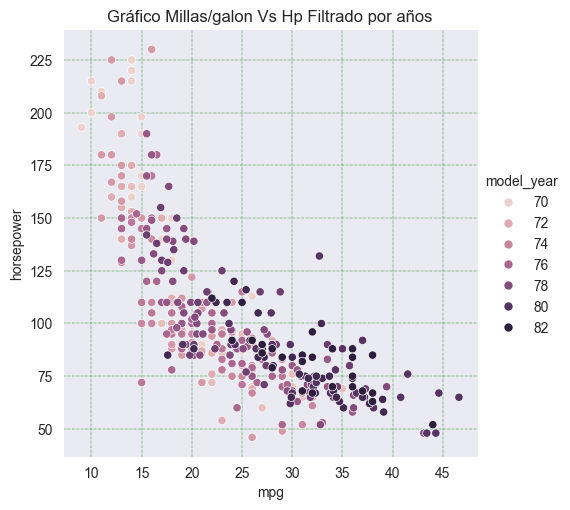

In [14]:
# filtramos por año:

sns.set_style('dark')

sns.relplot(data=df,
            x = 'mpg',
            y = 'horsepower',
            hue = 'model_year')


plt.grid(True, color='green', linestyle='-.', linewidth=0.3)
plt.title('Gráfico Millas/galon Vs Hp Filtrado por años')
plt.show()

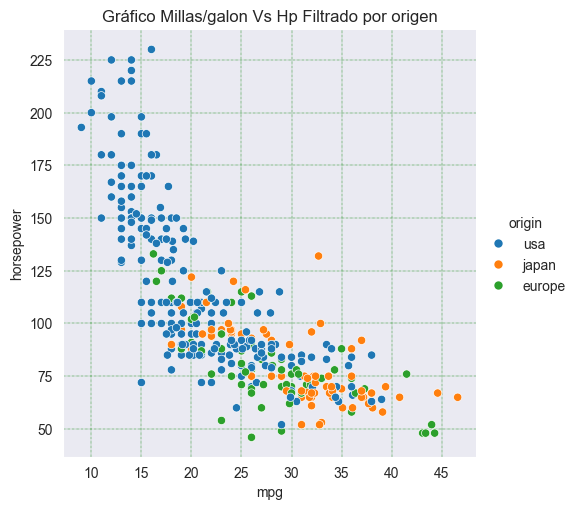

In [29]:
# filtramos por Origen:

sns.set_style('dark')

sns.relplot(data=df,
            x = 'mpg',
            y = 'horsepower',
            hue = 'origin')


plt.grid(True, color='green', linestyle='-.', linewidth=0.3)
plt.title('Gráfico Millas/galon Vs Hp Filtrado por origen')
plt.show()

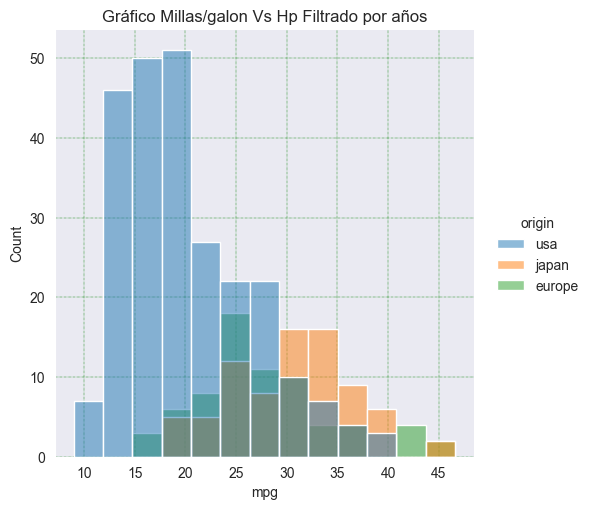

In [ ]:
# Histograma de millas por galon:


sns.displot(data=df,
            x = 'mpg',
            hue = 'origin')

plt.grid(True, color='green', linestyle='-.', linewidth=0.3)

plt.title('Histograma Millas/galon Filtrado por Origen')
plt.show()

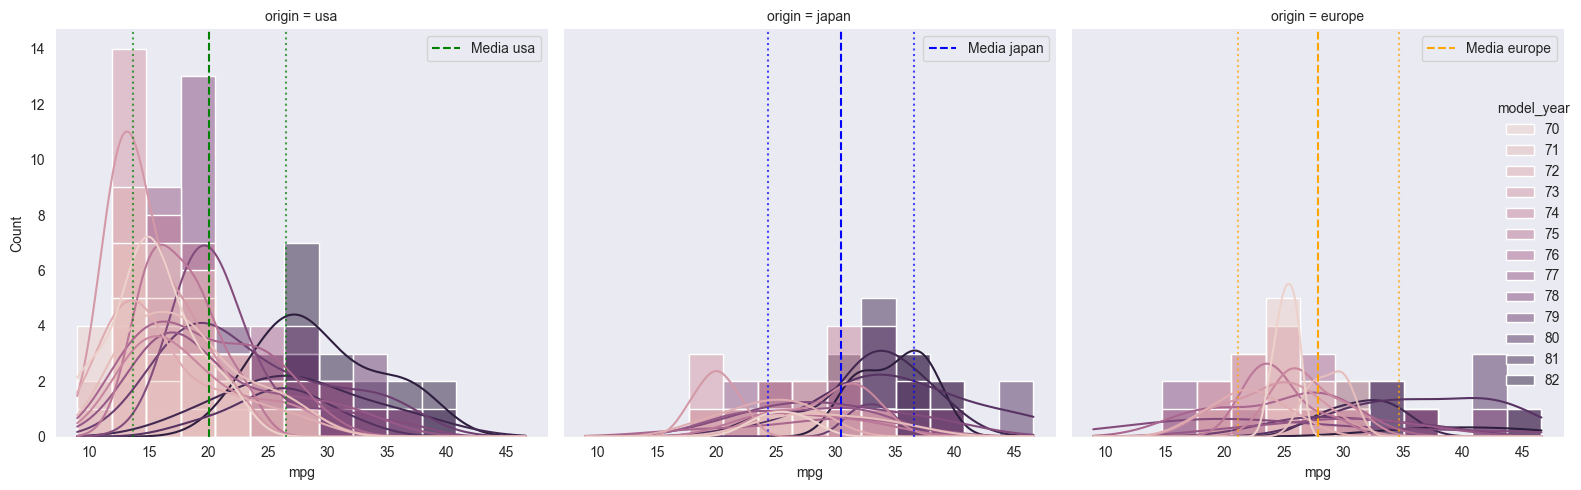

In [27]:
g = sns.displot(data= df, x = 'mpg', col='origin', hue= 'model_year', kde = True, color = 'skyblue' ) 

# Medias y desviaciones: 
# Calculando medias:
medusa = df[(df['origin'] == 'usa')]['mpg'].mean()
medjapan = df[(df['origin'] == 'japan')]['mpg'].mean()
medeurope = df[(df['origin'] == 'europe')]['mpg'].mean()

# Calculando desviaviones:
desusa = df[(df['origin'] == 'usa')]['mpg'].std()
desjapan = df[(df['origin'] == 'japan')]['mpg'].std()
deseurope = df[(df['origin'] == 'europe')]['mpg'].std()



# Diccionario con medias y desviaciones por origin
stats = {
    'usa': (medusa, desusa, 'green'),
    'japan': (medjapan, desjapan, 'blue'),
    'europe': (medeurope, deseurope, 'orange')
}

# Iterar sobre cada subplot y añadir líneas
for ax in g.axes.flat:
    origin = ax.get_title().split(' = ')[-1]  # Extrae el nombre del origrn del título
    media, ds, color = stats[origin]

    # Línea de la media
    ax.axvline(media, color=color, linestyle='--', label=f'Media {origin}')
    # Líneas de desviación estándar
    ax.axvline(media - ds, color=color, linestyle=':', alpha=0.7)
    ax.axvline(media + ds, color=color, linestyle=':', alpha=0.7)

    ax.legend()
plt.tight_layout()

In [26]:
print('MEDIA Y DESVIACIÓN ESTÁNDAR DE GALONES POR MILLA ')
print("Origen     Media    Desviación")
print("--------------------------------")

print(f"USA      {medusa:6.2f}    {desusa:6.2f}")
print(f"Japan    {medjapan:6.2f}    {desjapan:6.2f}")
print(f"Europe   {medeurope:6.2f}    {deseurope:6.2f}")


MEDIA Y DESVIACIÓN ESTÁNDAR DE GALONES POR MILLA 
Origen     Media    Desviación
--------------------------------
USA       20.08      6.40
Japan     30.45      6.09
Europe    27.89      6.72


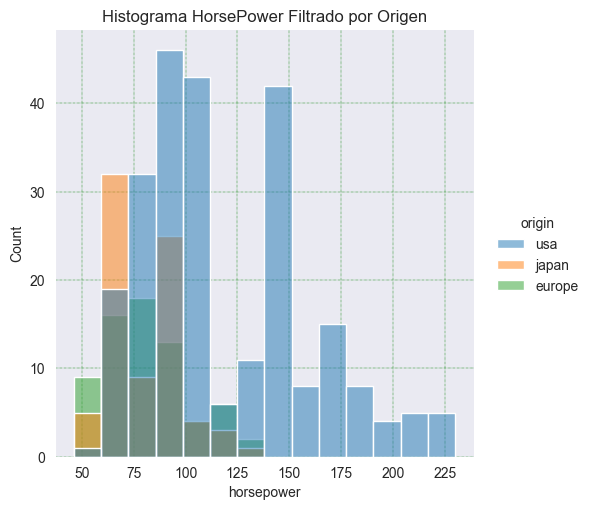

In [28]:
# Histograma de Horse Power por galon:


sns.displot(data=df,
            x = 'horsepower',
            hue = 'origin')

plt.grid(True, color='green', linestyle='-.', linewidth=0.3)

plt.title('Histograma HorsePower Filtrado por Origen')
plt.show()

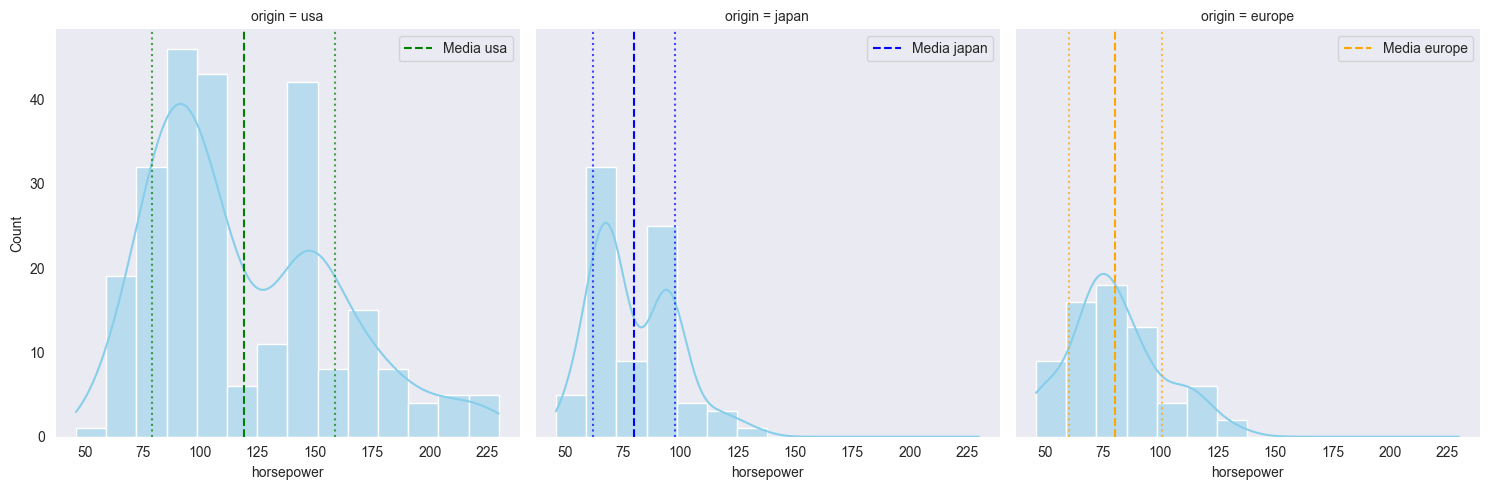

In [31]:
sns.set_style('dark')
g = sns.displot(data= df, x = 'horsepower', col='origin',  kde = True, color = 'skyblue' ) 

# Medias y desviaciones: 
# Calculando medias:
medusa = df[(df['origin'] == 'usa')]['horsepower'].mean()
medjapan = df[(df['origin'] == 'japan')]['horsepower'].mean()
medeurope = df[(df['origin'] == 'europe')]['horsepower'].mean()

# Calculando desviaviones:
desusa = df[(df['origin'] == 'usa')]['horsepower'].std()
desjapan = df[(df['origin'] == 'japan')]['horsepower'].std()
deseurope = df[(df['origin'] == 'europe')]['horsepower'].std()



# Diccionario con medias y desviaciones por origin
stats = {
    'usa': (medusa, desusa, 'green'),
    'japan': (medjapan, desjapan, 'blue'),
    'europe': (medeurope, deseurope, 'orange')
}

# Iterar sobre cada subplot y añadir líneas
for ax in g.axes.flat:
    origin = ax.get_title().split(' = ')[-1]  # Extrae el nombre del origrn del título
    media, ds, color = stats[origin]

    # Línea de la media
    ax.axvline(media, color=color, linestyle='--', label=f'Media {origin}')
    # Líneas de desviación estándar
    ax.axvline(media - ds, color=color, linestyle=':', alpha=0.7)
    ax.axvline(media + ds, color=color, linestyle=':', alpha=0.7)

    ax.legend()
plt.tight_layout()

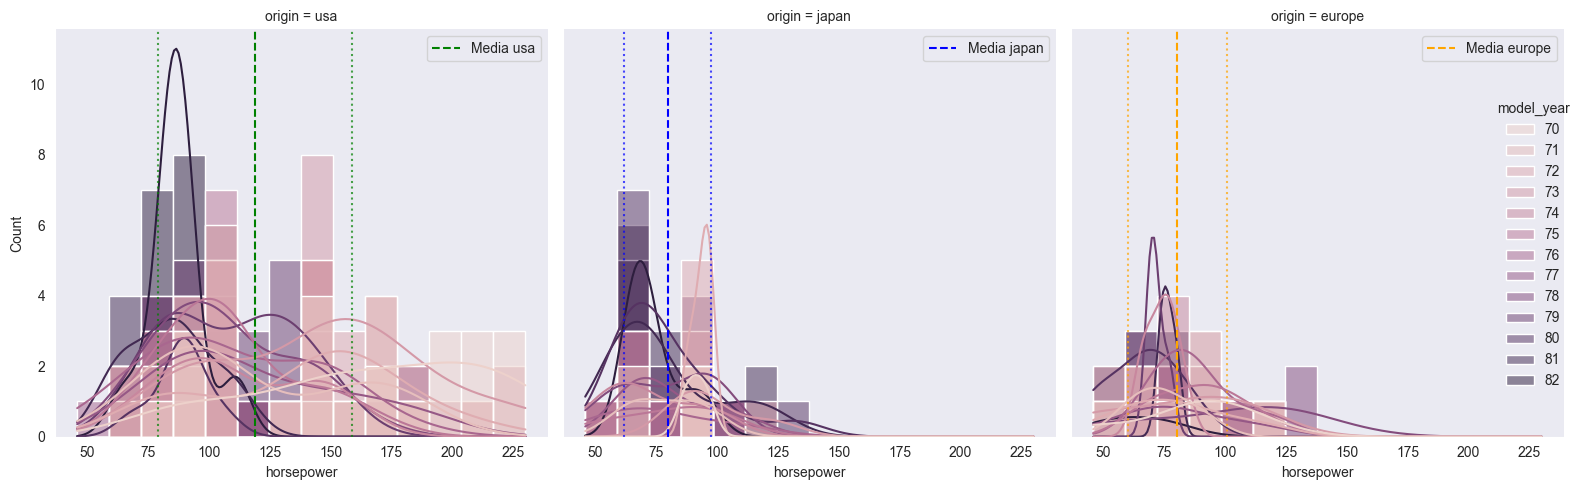

In [32]:
sns.set_style('dark')
g = sns.displot(data= df, x = 'horsepower', col='origin',  hue='model_year', kde = True, color = 'skyblue' ) 

# Medias y desviaciones: 
# Calculando medias:
medusa = df[(df['origin'] == 'usa')]['horsepower'].mean()
medjapan = df[(df['origin'] == 'japan')]['horsepower'].mean()
medeurope = df[(df['origin'] == 'europe')]['horsepower'].mean()

# Calculando desviaviones:
desusa = df[(df['origin'] == 'usa')]['horsepower'].std()
desjapan = df[(df['origin'] == 'japan')]['horsepower'].std()
deseurope = df[(df['origin'] == 'europe')]['horsepower'].std()



# Diccionario con medias y desviaciones por origin
stats = {
    'usa': (medusa, desusa, 'green'),
    'japan': (medjapan, desjapan, 'blue'),
    'europe': (medeurope, deseurope, 'orange')
}

# Iterar sobre cada subplot y añadir líneas
for ax in g.axes.flat:
    origin = ax.get_title().split(' = ')[-1]  # Extrae el nombre del origrn del título
    media, ds, color = stats[origin]

    # Línea de la media
    ax.axvline(media, color=color, linestyle='--', label=f'Media {origin}')
    # Líneas de desviación estándar
    ax.axvline(media - ds, color=color, linestyle=':', alpha=0.7)
    ax.axvline(media + ds, color=color, linestyle=':', alpha=0.7)

    ax.legend()
plt.tight_layout()

In [33]:
print('MEDIA Y DESVIACIÓN ESTÁNDAR DE HORSEPOWER ')
print("Origen     Media    Desviación")
print("--------------------------------")

print(f"USA      {medusa:6.2f}    {desusa:6.2f}")
print(f"Japan    {medjapan:6.2f}    {desjapan:6.2f}")
print(f"Europe   {medeurope:6.2f}    {deseurope:6.2f}")


MEDIA Y DESVIACIÓN ESTÁNDAR DE HORSEPOWER 
Origen     Media    Desviación
--------------------------------
USA      119.05     39.90
Japan     79.84     17.82
Europe    80.56     20.16
